# Compare P2 integer vs continuous solutions

Loads the two pickles from `model_speed.py` (`name`, `i`, `j`, `k`, `t`, `value`).

**Values plotted:** **Δ = value_continuous − value_base** (same units as the saved solution). **x**: signed Δ per site `i`. **y** and **z** heatmaps: **|Δ|** aggregated over time — first figure uses **max_t**, second uses **mean_t** (at each `(i,j)` for y; for z, at each `(i,j)` with fixed `k`).

**z:** one `(i,j)` heatmap per **k** ∈ {0,…,25} in a **7×4** grid (26 panels + 2 empty), shared color scale per figure.


In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run with working directory = folder that contains the .pkl files (e.g. light_version).
HERE = Path.cwd()
BASE_PKL = HERE / "P2_integer.pkl"
CONT_PKL = HERE / "P2_continuous.pkl"

df_base = pd.read_pickle(BASE_PKL)
df_cont = pd.read_pickle(CONT_PKL)

df_base = df_base.rename(columns={"value": "value_base"})
df_cont = df_cont.rename(columns={"value": "value_cont"})

merged = df_base.merge(df_cont, on=["name", "i", "j", "k", "t"], how="inner")
merged["diff"] = merged["value_cont"] - merged["value_base"]

assert len(merged) == len(df_base) == len(df_cont), "Row counts should align on keys"

N_GRID = 26


def _fill_ij_from_series(mat: np.ndarray, idx_i, idx_j, vals: np.ndarray) -> None:
    for ii, jj, v in zip(idx_i, idx_j, vals):
        mat[int(ii), int(jj)] = float(v)


def y_absdiff_matrix(merged_df: pd.DataFrame, stat: str) -> np.ndarray:
    """Per (i,j): mean_t or max_t of |value_cont - value_base| over t."""
    sub = merged_df[merged_df["name"] == "y"][["i", "j", "t", "diff"]].copy()
    sub["abs_diff"] = sub["diff"].abs()
    gb = sub.groupby(["i", "j"], as_index=False)
    if stat == "mean":
        g = gb["abs_diff"].mean().rename(columns={"abs_diff": "val"})
    else:
        g = gb["abs_diff"].max().rename(columns={"abs_diff": "val"})
    mat = np.full((N_GRID, N_GRID), np.nan, dtype=float)
    _fill_ij_from_series(mat, g["i"].values, g["j"].values, g["val"].values)
    return mat


def z_absdiff_matrix_at_k(merged_df: pd.DataFrame, k: int, stat: str) -> np.ndarray:
    """Fixed k: per (i,j), mean_t or max_t of |diff| over t."""
    sub = merged_df[(merged_df["name"] == "z") & (merged_df["k"] == int(k))][["i", "j", "t", "diff"]].copy()
    sub["abs_diff"] = sub["diff"].abs()
    gb = sub.groupby(["i", "j"], as_index=False)
    if stat == "mean":
        g = gb["abs_diff"].mean().rename(columns={"abs_diff": "val"})
    else:
        g = gb["abs_diff"].max().rename(columns={"abs_diff": "val"})
    mat = np.full((N_GRID, N_GRID), np.nan, dtype=float)
    _fill_ij_from_series(mat, g["i"].values, g["j"].values, g["val"].values)
    return mat


def z_absdiff_vmax(merged_df: pd.DataFrame, stat: str) -> float:
    mx = 0.0
    for k in range(N_GRID):
        arr = z_absdiff_matrix_at_k(merged_df, k, stat)
        if not np.any(np.isfinite(arr)):
            continue
        v = float(np.nanmax(arr))
        if np.isfinite(v):
            mx = max(mx, v)
    return mx if mx > 0 else 1.0

merged


,name,i,j,k,t,value_base,value_cont,diff
0,x,0,0,0,0,0.0,0,0.0
1,x,1,0,0,0,0.0,0,0.0
2,x,2,0,0,0,0.0,0,0.0
3,x,3,0,0,0,1.0,1,0.0
4,x,4,0,0,0,1.0,1,0.0
...,...,...,...,...,...,...,...,...
109533,z,25,25,25,1,0.0,0,0.0
109534,z,25,25,25,2,0.0,0,0.0
109535,z,25,25,25,3,0.0,0,0.0
109536,z,25,25,25,4,0.0,0,0.0


In [37]:
# Aggregate stats for the raw differences
stats = merged.groupby("name")["diff"].agg([
    ("max_abs_diff", lambda x: x.abs().max()),
    ("mean_abs_diff", lambda x: x.abs().mean()),
    ("count", "count")
])

print(stats)

      max_abs_diff  mean_abs_diff   count
name                                     
x              0.0       0.000000      26
y           8107.0       4.028600    4056
z           1190.0       0.023906  105456


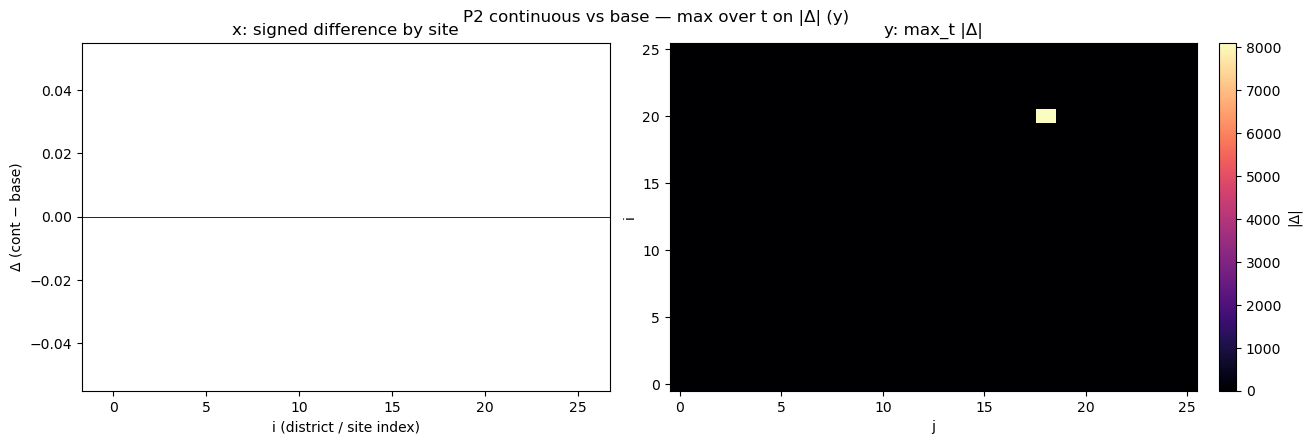

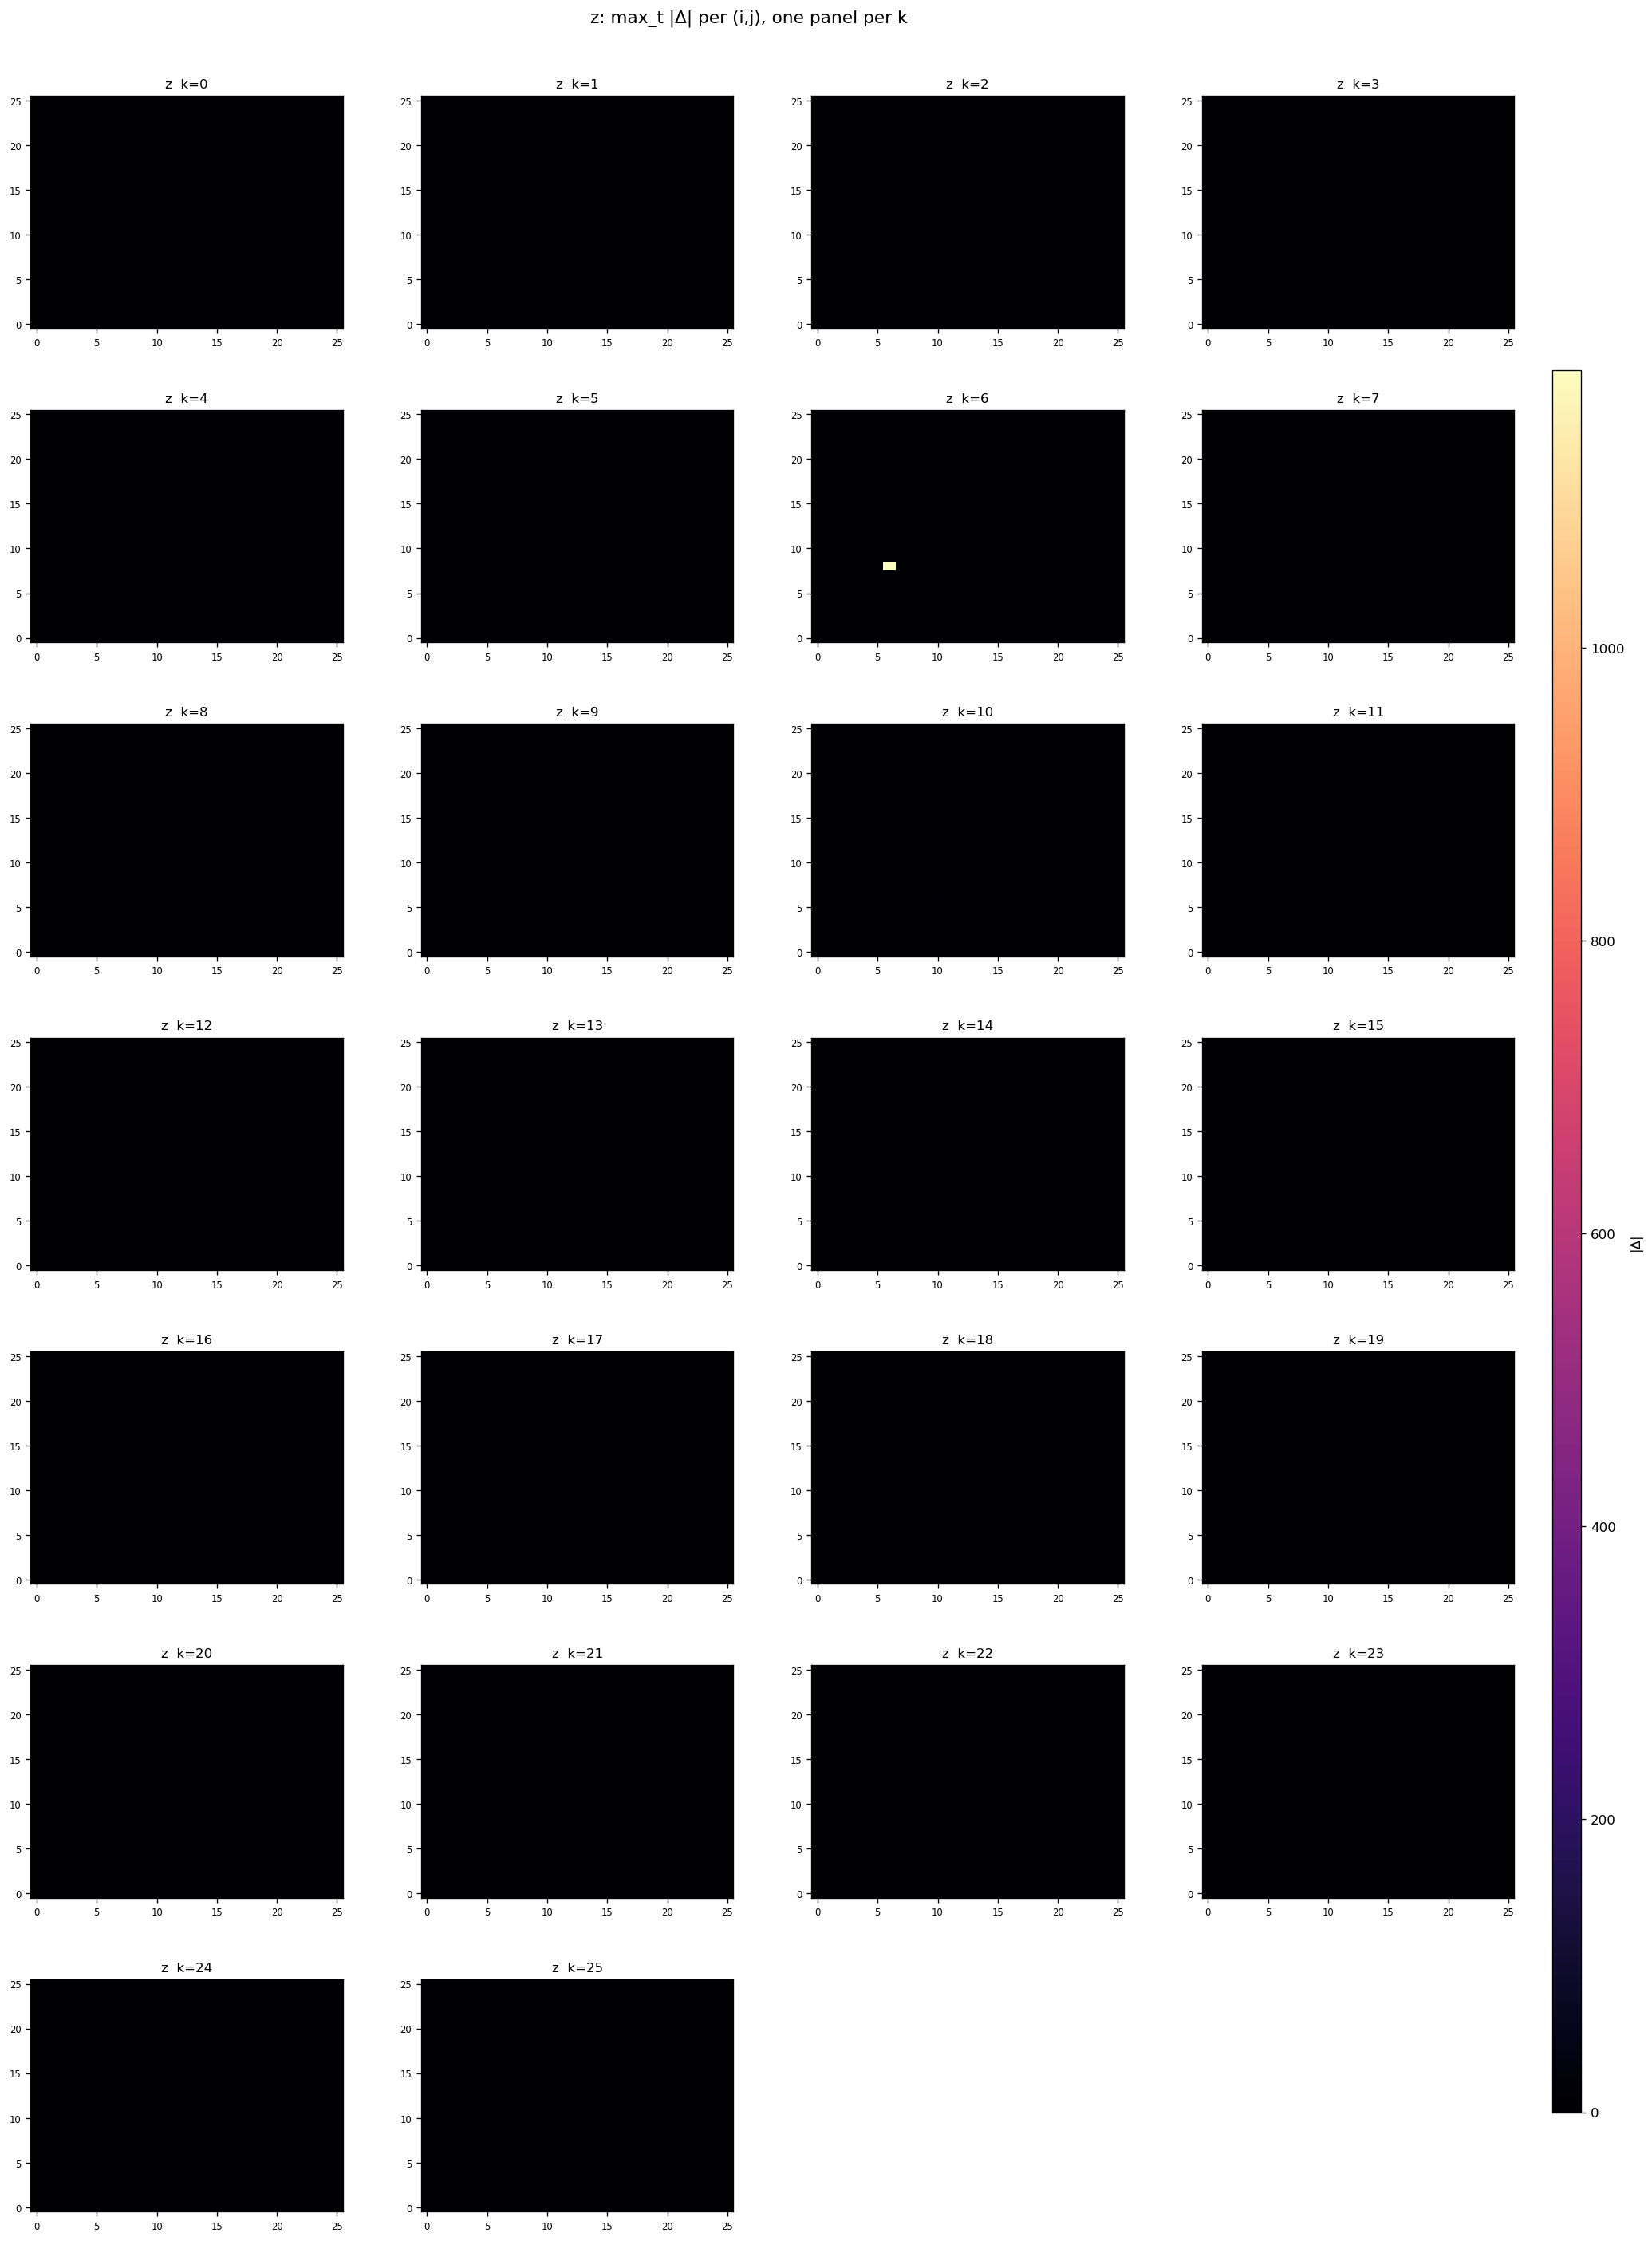

In [40]:
# Raw Δ = value_cont − value_base. y,z heatmaps: |Δ| aggregated over t (max vs mean). z: 7×4 grid over k.
dx = merged[merged["name"] == "x"].sort_values("i")
mat_y = y_absdiff_matrix(merged, stat="max")
z_vmax = z_absdiff_vmax(merged, "max")

fig_xy, axes_xy = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
axes_xy[0].bar(dx["i"], dx["diff"], color="steelblue", edgecolor="none")
axes_xy[0].axhline(0, color="k", lw=0.6)
axes_xy[0].set_xlabel("i (district / site index)")
axes_xy[0].set_ylabel("Δ (cont − base)")
axes_xy[0].set_title("x: signed difference by site")
axes_xy[0].set_xticks(range(0, 26, 5))

_yv = np.nanmax(mat_y)
_yv = _yv if np.isfinite(_yv) and _yv > 0 else 1.0
im_y = axes_xy[1].imshow(mat_y, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=_yv)
axes_xy[1].set_xlabel("j")
axes_xy[1].set_ylabel("i")
axes_xy[1].set_title("y: max_t |Δ|")
fig_xy.colorbar(im_y, ax=axes_xy[1], fraction=0.046, pad=0.04, label="|Δ|")
fig_xy.suptitle("P2 continuous vs base — max over t on |Δ| (y)", fontsize=12, y=1.02)
plt.show()

fig_z, axes_z = plt.subplots(7, 4, figsize=(20, 26), dpi=120)
axes_flat = axes_z.ravel()
im_last = None
for k in range(26):
    ax = axes_flat[k]
    arr = z_absdiff_matrix_at_k(merged, k, stat="max")
    im_last = ax.imshow(arr, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=z_vmax)
    ax.set_title(f"z  k={k}", fontsize=10)
    ax.tick_params(axis="both", labelsize=7)
    if k % 4 != 0:
        ax.set_ylabel("")
    if k < 22:
        ax.set_xlabel("")
for idx in range(26, 28):
    axes_flat[idx].axis("off")

fig_z.subplots_adjust(right=0.9, top=0.96, hspace=0.35, wspace=0.25)
cax = fig_z.add_axes([0.92, 0.15, 0.015, 0.7])
fig_z.colorbar(im_last, cax=cax, label="|Δ|")
fig_z.suptitle("z: max_t |Δ| per (i,j), one panel per k", fontsize=13, y=0.995)
plt.show()


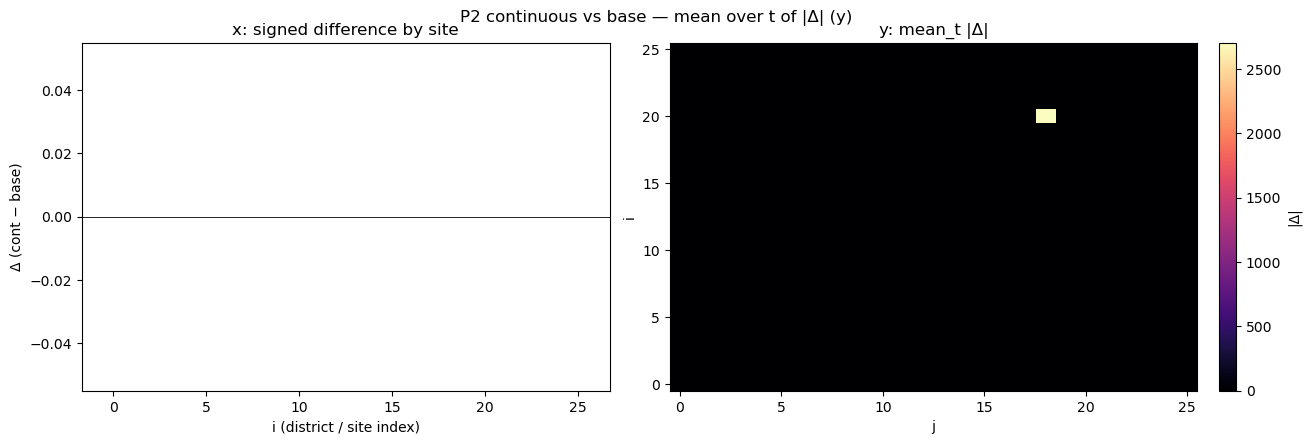

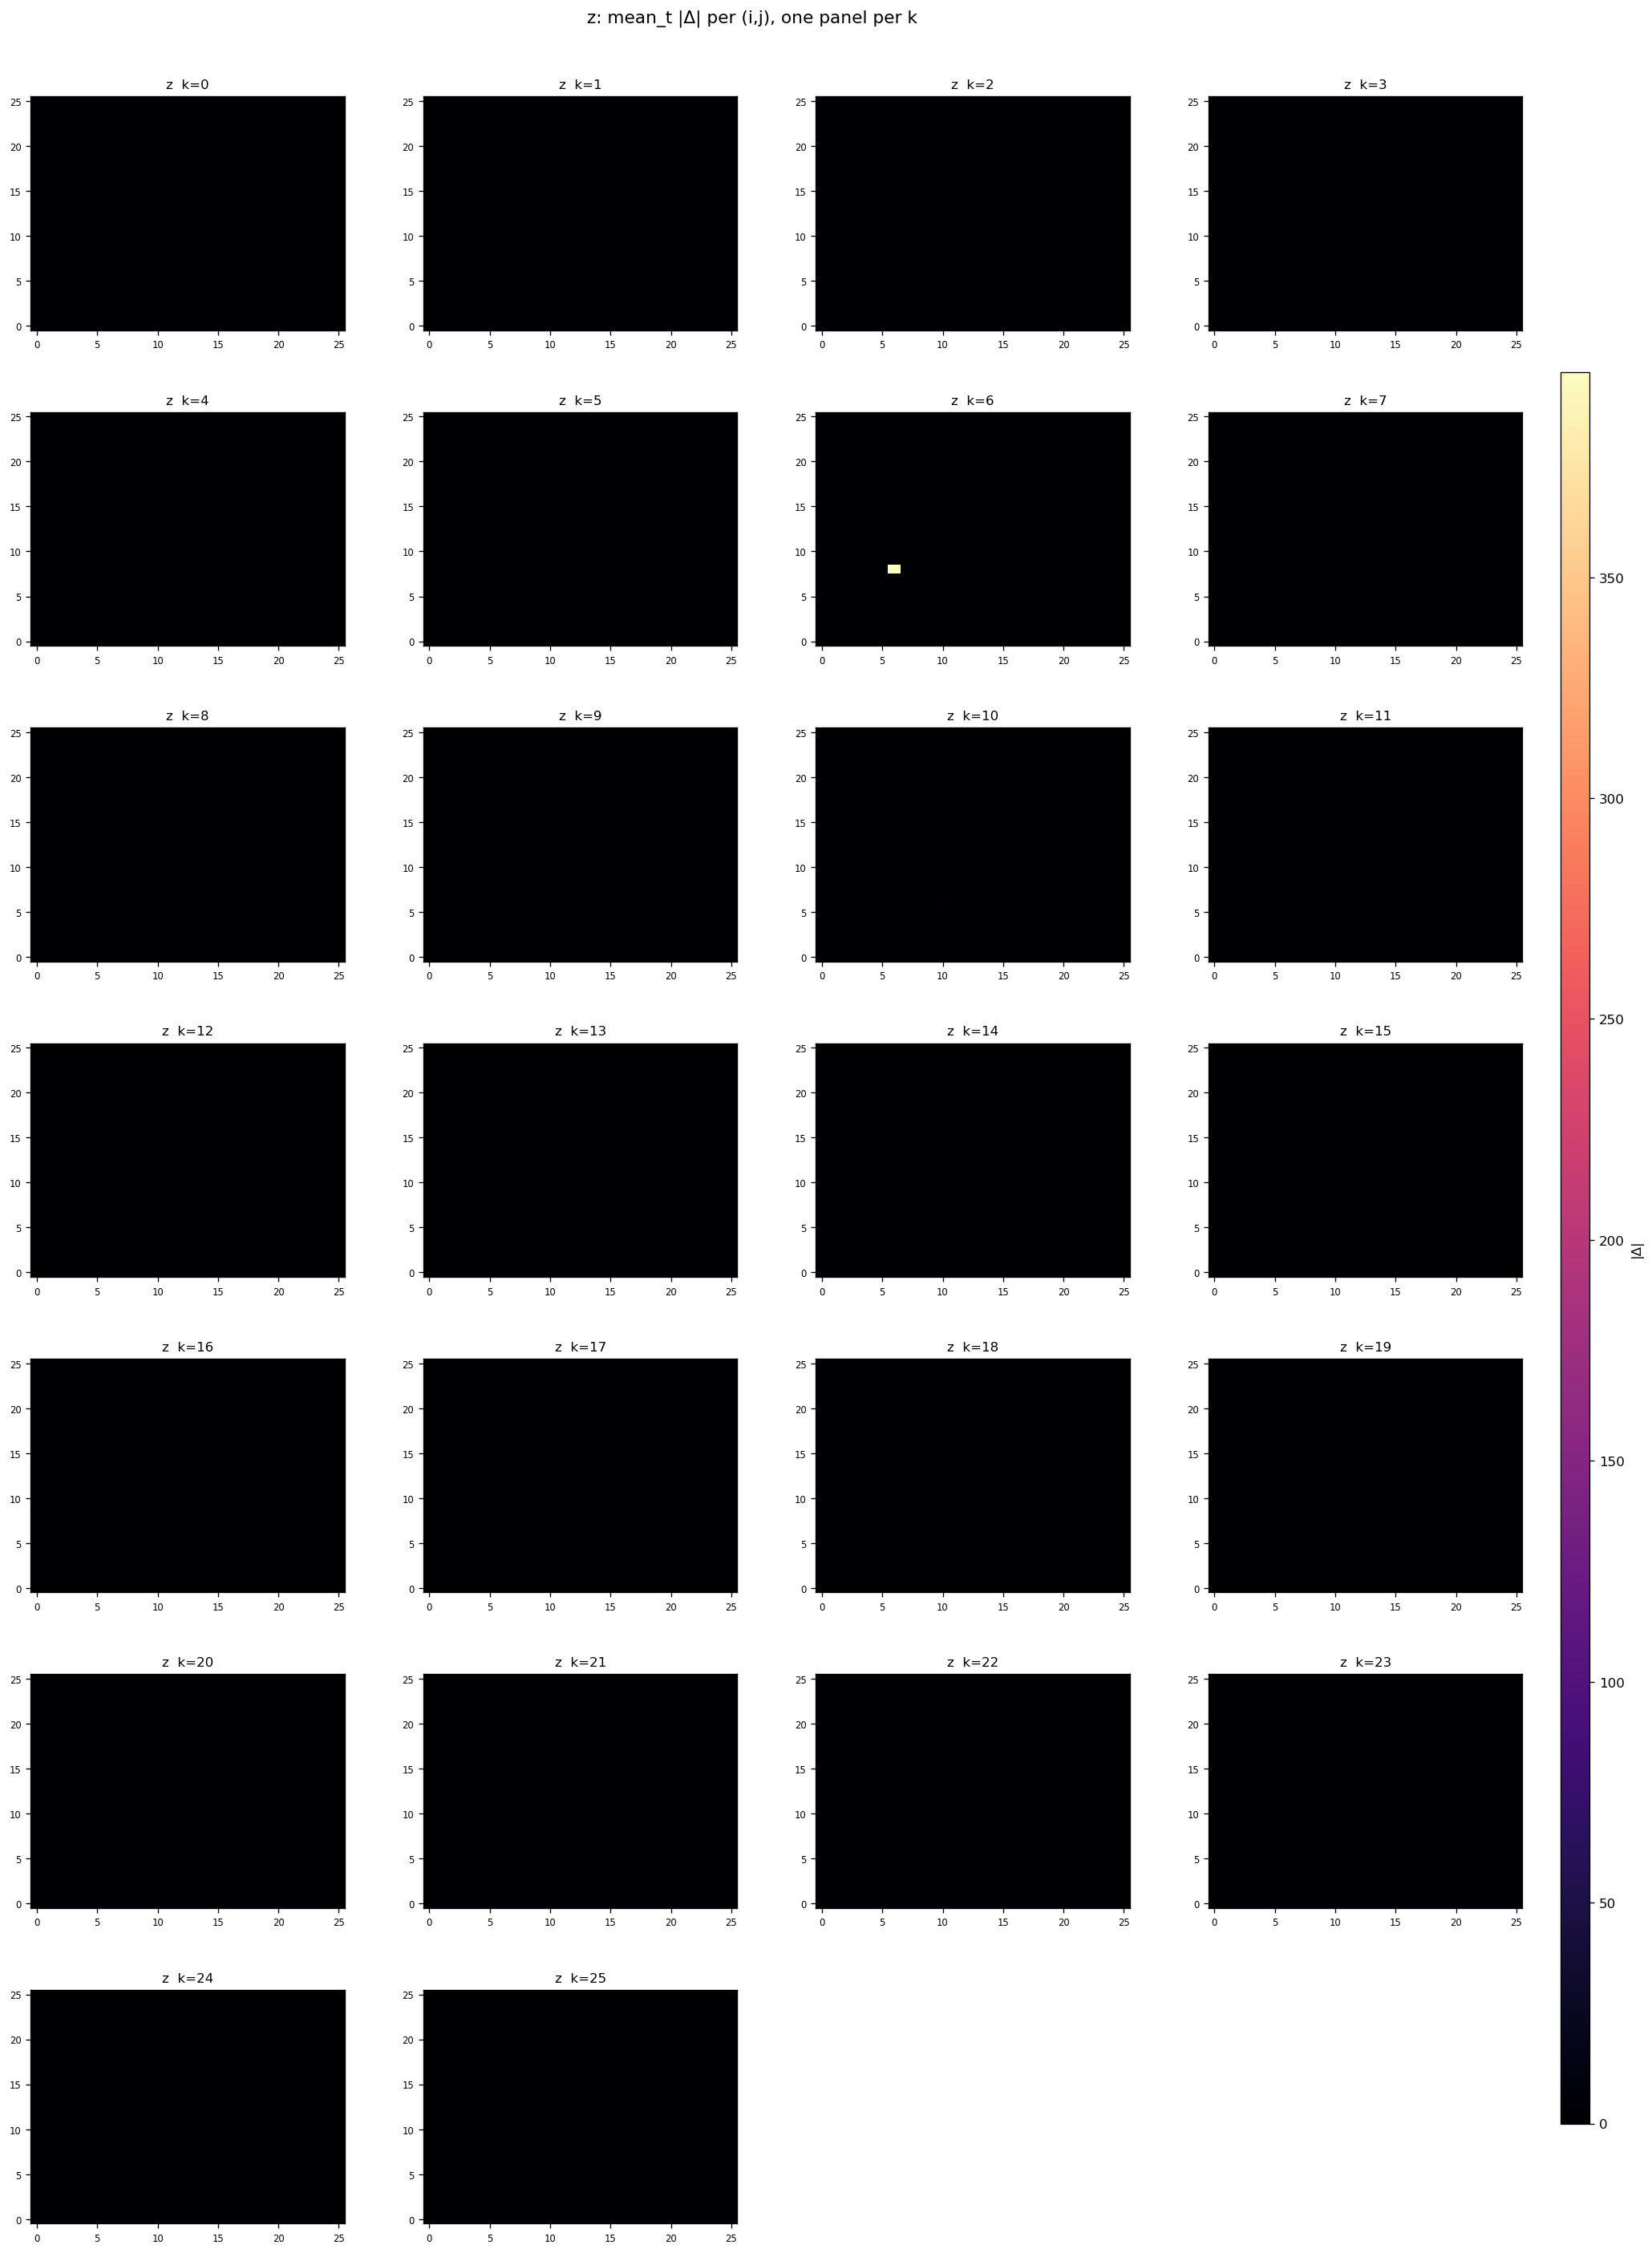

In [41]:
# Same layout; y and z use mean_t |Δ|.
dx = merged[merged["name"] == "x"].sort_values("i")
mat_y = y_absdiff_matrix(merged, stat="mean")
z_vmax = z_absdiff_vmax(merged, "mean")

fig_xy, axes_xy = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
axes_xy[0].bar(dx["i"], dx["diff"], color="steelblue", edgecolor="none")
axes_xy[0].axhline(0, color="k", lw=0.6)
axes_xy[0].set_xlabel("i (district / site index)")
axes_xy[0].set_ylabel("Δ (cont − base)")
axes_xy[0].set_title("x: signed difference by site")
axes_xy[0].set_xticks(range(0, 26, 5))

_yv = np.nanmax(mat_y)
_yv = _yv if np.isfinite(_yv) and _yv > 0 else 1.0
im_y = axes_xy[1].imshow(mat_y, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=_yv)
axes_xy[1].set_xlabel("j")
axes_xy[1].set_ylabel("i")
axes_xy[1].set_title("y: mean_t |Δ|")
fig_xy.colorbar(im_y, ax=axes_xy[1], fraction=0.046, pad=0.04, label="|Δ|")
fig_xy.suptitle("P2 continuous vs base — mean over t of |Δ| (y)", fontsize=12, y=1.02)
plt.show()

fig_z, axes_z = plt.subplots(7, 4, figsize=(20, 26), dpi=120)
axes_flat = axes_z.ravel()
im_last = None
for k in range(26):
    ax = axes_flat[k]
    arr = z_absdiff_matrix_at_k(merged, k, stat="mean")
    im_last = ax.imshow(arr, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=z_vmax)
    ax.set_title(f"z  k={k}", fontsize=10)
    ax.tick_params(axis="both", labelsize=7)
    if k % 4 != 0:
        ax.set_ylabel("")
    if k < 22:
        ax.set_xlabel("")
for idx in range(26, 28):
    axes_flat[idx].axis("off")

fig_z.subplots_adjust(right=0.9, top=0.96, hspace=0.35, wspace=0.25)
cax = fig_z.add_axes([0.92, 0.15, 0.015, 0.7])
fig_z.colorbar(im_last, cax=cax, label="|Δ|")
fig_z.suptitle("z: mean_t |Δ| per (i,j), one panel per k", fontsize=13, y=0.995)
plt.show()


In [42]:
# Quick scalar summaries (optional)
for nm in ["x", "y", "z"]:
    d = merged.loc[merged["name"] == nm, "diff"]
    print(
        f"{nm}: max|Δ|={d.abs().max():.6g},  mean|Δ|={d.abs().mean():.6g},  rows={len(d)}"
    )

x: max|Δ|=0,  mean|Δ|=0,  rows=26
y: max|Δ|=8107,  mean|Δ|=4.0286,  rows=4056
z: max|Δ|=1190,  mean|Δ|=0.0239057,  rows=105456


In [43]:
merged[merged['diff']>10]


,name,i,j,k,t,value_base,value_cont,diff
3259,y,20,18,0,5,0.0,8105,8105.0
30038,z,6,10,10,0,1546.0,1557,11.0
37507,z,8,6,6,5,0.0,1189,1189.0


In [44]:
merged[merged['diff']<-10]

,name,i,j,k,t,value_base,value_cont,diff
3258,y,20,18,0,4,332926.0,324819,-8107.0
30039,z,6,10,10,1,3719.0,3707,-12.0
37506,z,8,6,6,4,1757.0,567,-1190.0


base: 2.595597359020e+08
cont: 2.595595218084e+08






In [46]:
((2.595597359020e+08-2.595595218084e+08)/2.595597359020e+08)*100

8.248336332324869e-05

In [45]:
sum(merged['value_base'])-sum(merged['value_cont'])

73.0